# Classificação de Imagens com MobileNetV3 (timm)

Este notebook demonstra como carregar um modelo pré-treinado da biblioteca `timm` (PyTorch Image Models) e utilizá-lo para classificar as imagens contidas na pasta `images/`.

O modelo utilizado é o `mobilenetv3_small_100.lamb_in1k`.

In [9]:
import torch
import timm
from PIL import Image
from torchvision import transforms
import os
import json
import urllib.request
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Verificar disponibilidade de GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# 2. Carregar o modelo pré-treinado
model_name = 'mobilenetv3_small_100.lamb_in1k'
model = timm.create_model(model_name, pretrained=True)
model = model.to(device)
model.eval()

print(f"Modelo {model_name} carregado com sucesso!")

Usando dispositivo: cpu
Modelo mobilenetv3_small_100.lamb_in1k carregado com sucesso!


## 3. Baixar os nomes das classes do ImageNet (Labels)
Como o modelo retorna apenas índices numéricos, precisamos deste mapeamento para ver nomes legíveis.

In [10]:
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels_path = "imagenet_classes.txt"

if not os.path.exists(labels_path):
    print("Baixando nomes das classes do ImageNet...")
    urllib.request.urlretrieve(labels_url, labels_path)
    print("Download concluído!")
else:
    print("Arquivo de labels já existe localmente.")

with open(labels_path, "r") as f:
    categories = [s.strip() for s in f.readlines()]

print(f"{len(categories)} labels carregados!")

Arquivo de labels já existe localmente.
1000 labels carregados!


## 4. Configurar Transformações
Precisamos redimensionar a imagem e normalizá-la de acordo com o que o modelo espera.

In [11]:
# Obter configurações de dados específicas do modelo (resolução, média, desvio padrão)
data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)

print("Transformações configuradas:")
print(transform)

Transformações configuradas:
Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


## 5. Função de Predição (Top-5)
Uma função que retorna o Top-5 de classes e probabilidades.

In [12]:
def classify_image_top5(image_path):
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
    
    # Pegar as TOP 5
    top5_prob, top5_catid = torch.topk(probabilities, 5)
    
    results = []
    for i in range(5):
        results.append({
            "label": categories[top5_catid[i].item()],
            "probability": top5_prob[i].item()
        })
        
    return results

## 6. Processar Imagens com Gráfico do Top-5

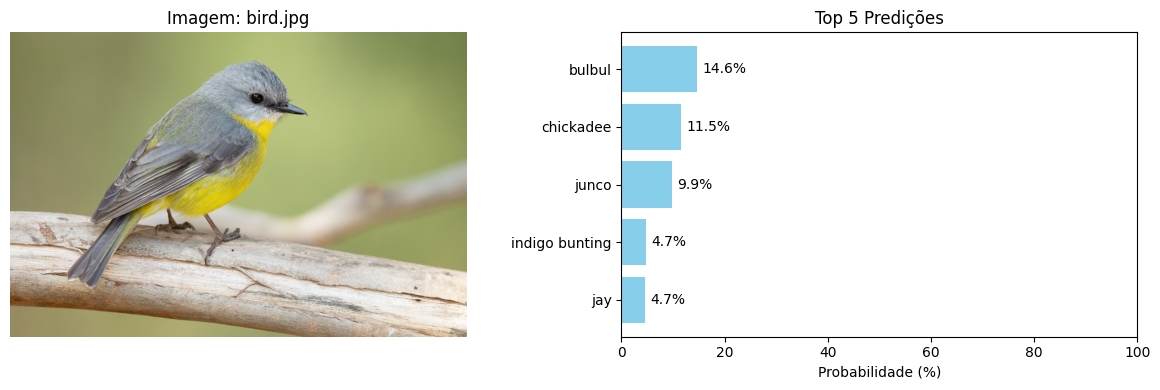

--------------------------------------------------------------------------------


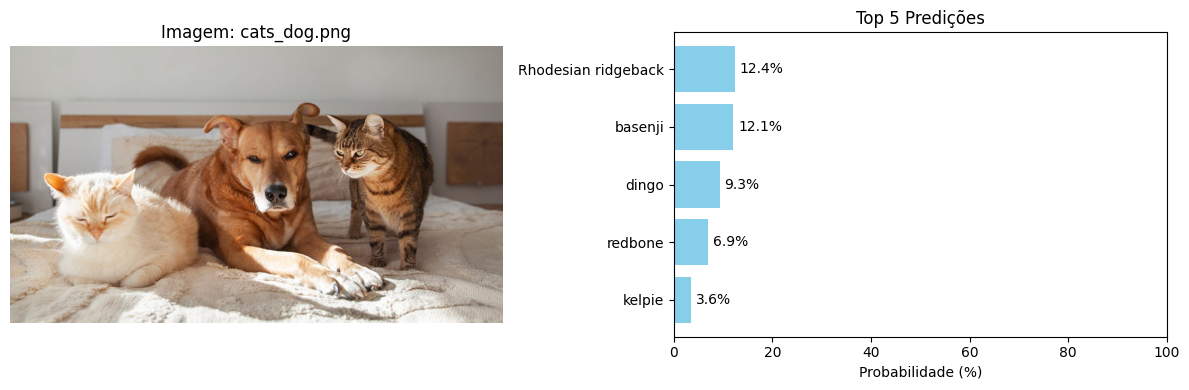

--------------------------------------------------------------------------------


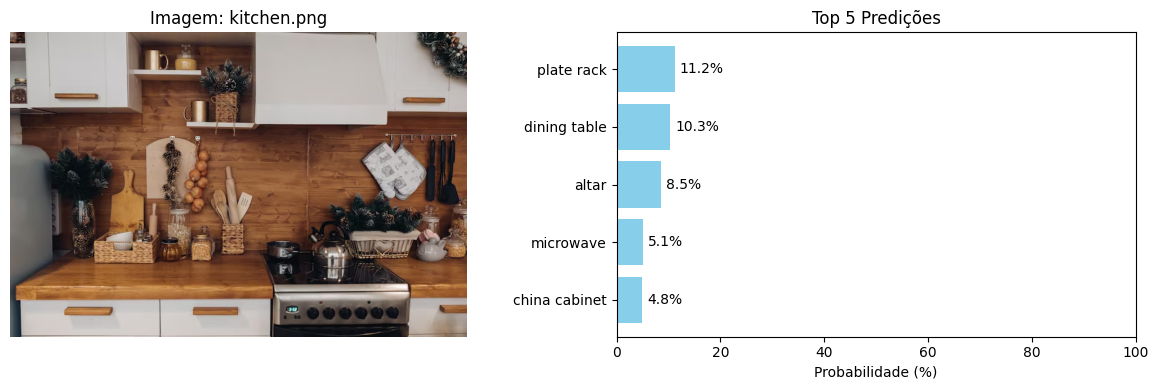

--------------------------------------------------------------------------------


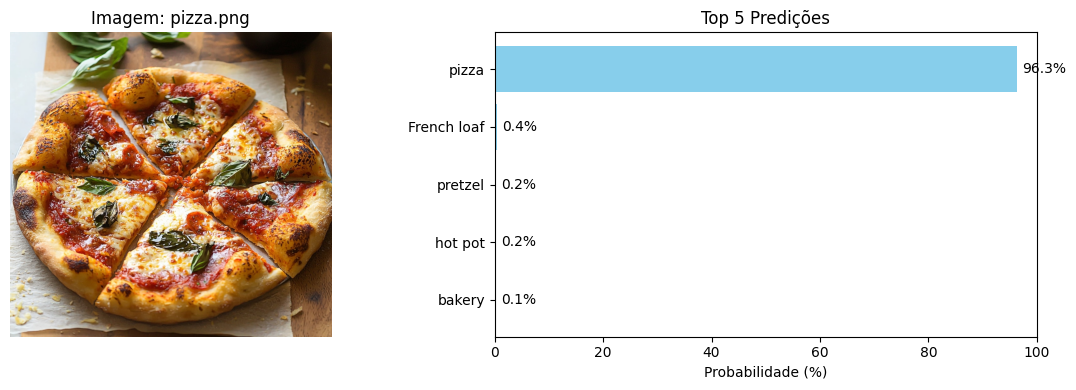

--------------------------------------------------------------------------------


In [13]:
images_dir = "images"
allowed_extensions = (".png", ".jpg", ".jpeg")

for filename in os.listdir(images_dir):
    if filename.lower().endswith(allowed_extensions):
        path = os.path.join(images_dir, filename)
        
        # Classificar
        top5_results = classify_image_top5(path)
        
        # Criar Visualização com Matplotlib
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # 1. Mostrar Imagem
        img = Image.open(path)
        ax1.imshow(img)
        ax1.axis('off')
        ax1.set_title(f"Imagem: {filename}")
        
        # 2. Gráfico de Barras do Top-5
        labels = [res["label"] for res in top5_results][::-1]  # Inverter para gráfico horizontal
        probs = [res["probability"] * 100 for res in top5_results][::-1]
        
        bars = ax2.barh(labels, probs, color='skyblue')
        ax2.set_xlabel('Probabilidade (%)')
        ax2.set_xlim(0, 100)
        ax2.set_title("Top 5 Predições")
        
        # Adicionar valores nas barras
        for bar in bars:
            width = bar.get_width()
            ax2.text(width + 1, bar.get_y() + bar.get_height()/2, 
                     f'{width:.1f}%', ha='left', va='center')
        
        plt.tight_layout()
        plt.show()
        print("-" * 80)